In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mtick

In [3]:
filename = "results.txt"

headers = ["filename", 
            "num_threads",
            "n", 
            "m", 
            "included", 
            "excluded",
            "num_groups", 
            "type",
            "greedy_time", 
            "greedy_size",
            "grasp_time", 
            "grasp_size"]
df = pd.read_csv(filename, sep=r'\s+', header=None, names=headers, na_values=["nan"])
df.head()

,filename,num_threads,n,m,included,excluded,num_groups,type,greedy_time,greedy_size,grasp_time,grasp_size
0,scp41,1,200,1000,0,95,0,NaN,0.001193,41,0.013371,40
1,scp41,2,200,1000,0,95,0,NaN,0.001123,41,0.009551,38
2,scp41,4,200,1000,0,95,0,NaN,0.001240,41,0.008948,40
3,scp41,8,200,1000,0,95,0,NaN,0.001144,41,0.008253,40
4,scp41,16,200,1000,0,95,0,NaN,0.001187,41,0.008197,40


In [4]:
# params
plt.style.use('seaborn-v0_8-paper')

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13, 
    'axes.titlesize': 15,   
    'xtick.labelsize': 10,   
    'ytick.labelsize': 12,   
    'legend.fontsize': 11,
    'lines.markersize': 9,
})
cyan = "#3BB3BA"
red = '#E45B5B'

# GRASP BASE

### Cardinalidad vs BKS

In [39]:
datasets = [
    ["scpe1", "scpe2", "scpe3", "scpe4", "scpe5", "scpclr10", "scpclr11", "scpclr12", "scpclr13", "scpcyc06", "scpcyc07", "scpcyc08", "scpcyc09", "scpcyc10", "scpcyc11"],
    [5, 5, 5, 5, 5, 25, 23, 23, 23, 60, 144, 344, 772, 1792, 3968]
]
bks_map = dict(zip(datasets[0], datasets[1]))
saveFilename = "graspRPD"
nt = 1

/tmp/ipykernel_807059/483458517.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["instance_size"] = df_filtered.apply(lambda row: f"({row['n']}, {row['m']})", axis=1)
/tmp/ipykernel_807059/483458517.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_time.sort_values(by=["m", "n"], inplace=True)


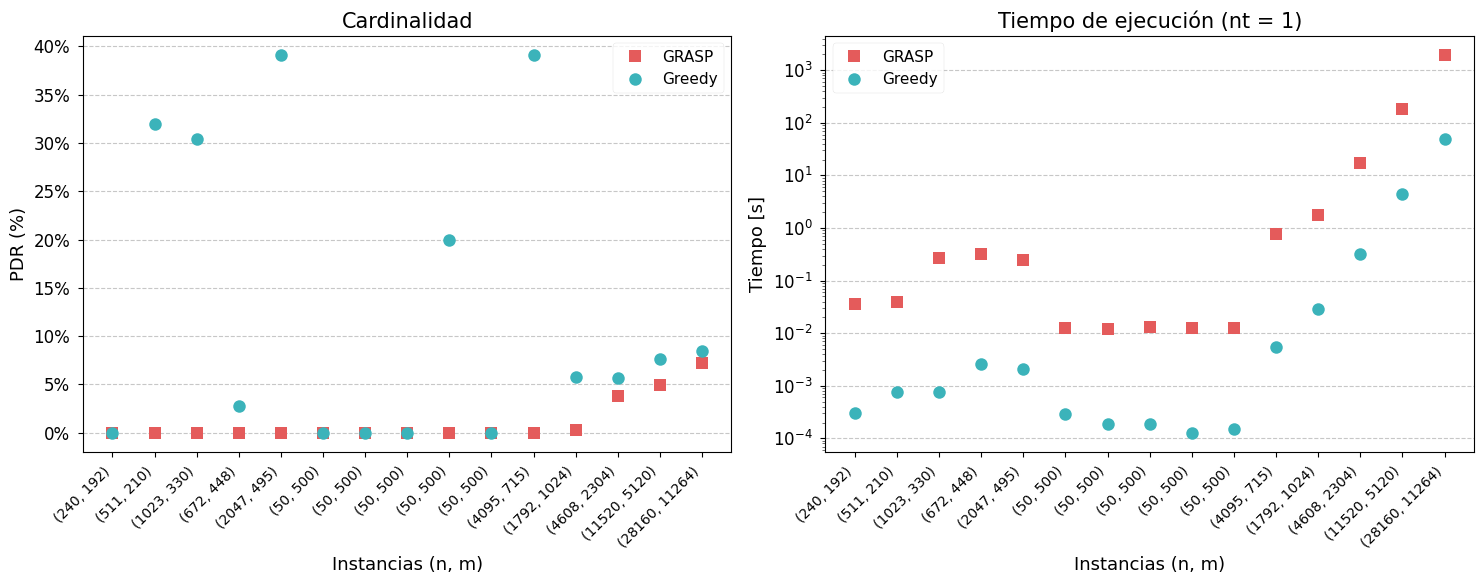

In [40]:
df_filtered = df[df["filename"].isin(datasets[0]) & pd.isna(df["type"])]
df_filtered["instance_size"] = df_filtered.apply(lambda row: f"({row['n']}, {row['m']})", axis=1)
df_sc = df_filtered.loc[df_filtered.groupby("filename")["grasp_size"].idxmin()].reset_index(drop=True)
df_sc['BKS'] = df_sc['filename'].map(bks_map)
df_sc.sort_values(by=["m", "n"], inplace=True)

df_sc["impr_grasp"] = ((df_sc["grasp_size"] - df_sc["BKS"]) / df_sc["BKS"]) * 100
df_sc["impr_greedy"] = ((df_sc["greedy_size"] - df_sc["BKS"]) / df_sc["BKS"]) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
x = np.arange(len(df_sc["instance_size"]))
# width = 0.4

# ax1.bar(x - width/2, df_sc["impr_grasp"], width, label='GRASP_SU', color=red)
# ax1.bar(x + width/2, df_sc["impr_greedy"], width, label='GRASP', color=cyan)

ax1.plot(x, df_sc["impr_grasp"], marker='s', label='GRASP', linestyle='None', color=red)
ax1.plot(x, df_sc["impr_greedy"], marker='o', label='Greedy', linestyle='None', color=cyan)

ax1.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))

ax1.set_xticks(x)
ax1.set_xticklabels(df_sc['instance_size'], rotation=45, ha='right')
ax1.set_xlabel("Instancias (n, m)")
ax1.set_title("Cardinalidad")
ax1.set_ylabel("PDR (%)")
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

df_time = df_filtered[df_filtered["num_threads"] == nt]
df_time.sort_values(by=["m", "n"], inplace=True)

ax2.plot(x, df_time["grasp_time"], marker='s', label=f'GRASP', linestyle='None', color=red)
ax2.plot(x, df_time["greedy_time"], marker='o', label='Greedy', linestyle='None', color=cyan)

ax2.set_xticks(x)
ax2.set_xticklabels(df_time['instance_size'], rotation=45, ha='right')
ax2.set_xlabel("Instancias (n, m)")
ax2.set_title(f"Tiempo de ejecución (nt = {nt})")
ax2.set_ylabel("Tiempo [s]")
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.set_yscale('log')
# ax2.set_ylim(bottom=0)

plt.tight_layout()

plt.savefig(f"images/{saveFilename}.png", dpi=300, bbox_inches='tight')
plt.show()

In [19]:
datasets = [
    ["rail507", "rail516", "rail582", "rail2536", "rail2586", "rail4284", "rail4872"],
    [96, 134, 125, 377, 518, 591, 877]
]
bks_map = dict(zip(datasets[0], datasets[1]))
saveFilename = "graspRPDrailways"
nt = 32

/tmp/ipykernel_807059/3781744851.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["instance_size"] = df_filtered.apply(lambda row: f"({row['n']}, {row['m']})", axis=1)
/tmp/ipykernel_807059/3781744851.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_time.sort_values(by=["m", "n"], inplace=True)


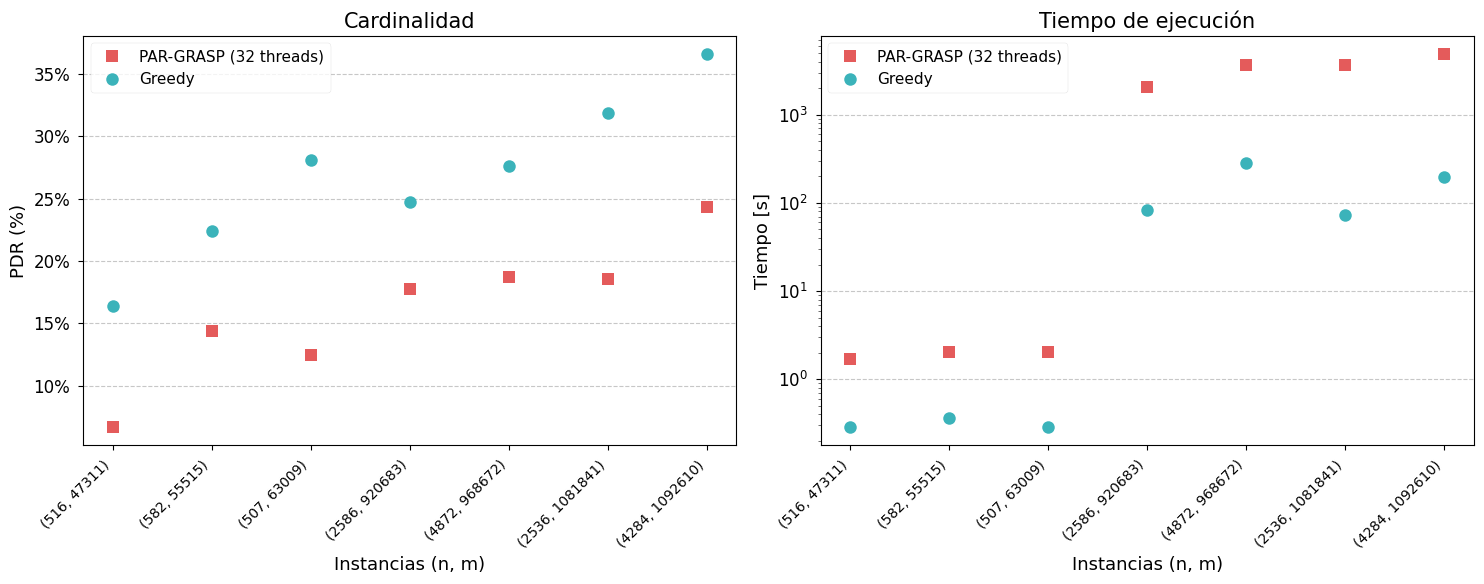

In [22]:
df_filtered = df[df["filename"].isin(datasets[0]) & pd.isna(df["type"])]
df_filtered["instance_size"] = df_filtered.apply(lambda row: f"({row['n']}, {row['m']})", axis=1)
df_sc = df_filtered.loc[df_filtered.groupby("filename")["grasp_size"].idxmin()].reset_index(drop=True)
df_sc['BKS'] = df_sc['filename'].map(bks_map)
df_sc.sort_values(by=["m", "n"], inplace=True)

df_sc["impr_grasp"] = ((df_sc["grasp_size"] - df_sc["BKS"]) / df_sc["BKS"]) * 100
df_sc["impr_greedy"] = ((df_sc["greedy_size"] - df_sc["BKS"]) / df_sc["BKS"]) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
x = np.arange(len(df_sc["instance_size"]))

ax1.plot(x, df_sc["impr_grasp"], marker='s', label='PAR-GRASP (32 threads)', linestyle='None', color=red)
ax1.plot(x, df_sc["impr_greedy"], marker='o', label='Greedy', linestyle='None', color=cyan)

ax1.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))

ax1.set_xticks(x)
ax1.set_xticklabels(df_sc['instance_size'], rotation=45, ha='right')
ax1.set_xlabel("Instancias (n, m)")
ax1.set_title("Cardinalidad")
ax1.set_ylabel("PDR (%)")
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

df_time = df_filtered[df_filtered["num_threads"] == nt]
df_time.sort_values(by=["m", "n"], inplace=True)

ax2.plot(x, df_time["grasp_time"], marker='s', label=f'PAR-GRASP (32 threads)', linestyle='None', color=red)
ax2.plot(x, df_time["greedy_time"], marker='o', label='Greedy', linestyle='None', color=cyan)

ax2.set_xticks(x)
ax2.set_xticklabels(df_time['instance_size'], rotation=45, ha='right')
ax2.set_xlabel("Instancias (n, m)")
ax2.set_title(f"Tiempo de ejecución")
ax2.set_ylabel("Tiempo [s]")
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.set_yscale('log')
# ax2.set_ylim(bottom=0)

plt.tight_layout()

plt.savefig(f"images/{saveFilename}.png", dpi=300, bbox_inches='tight')
plt.show()

### Speedup

In [5]:
dataset_name = "rail582"

In [ ]:
column_time = [
    33.284919,
    16.112811,
    8.205974,
    4.204324,
    2.139558,
    1.084598
]
create_map = [
    0.125840,
    0.063488,
    0.032247,
    0.017001,
    0.009442,
    0.005755
]
total_time = [
    33.4917,
    16.2587,
    8.32403,
    4.31118,
    2.23272,
    1.17801
]

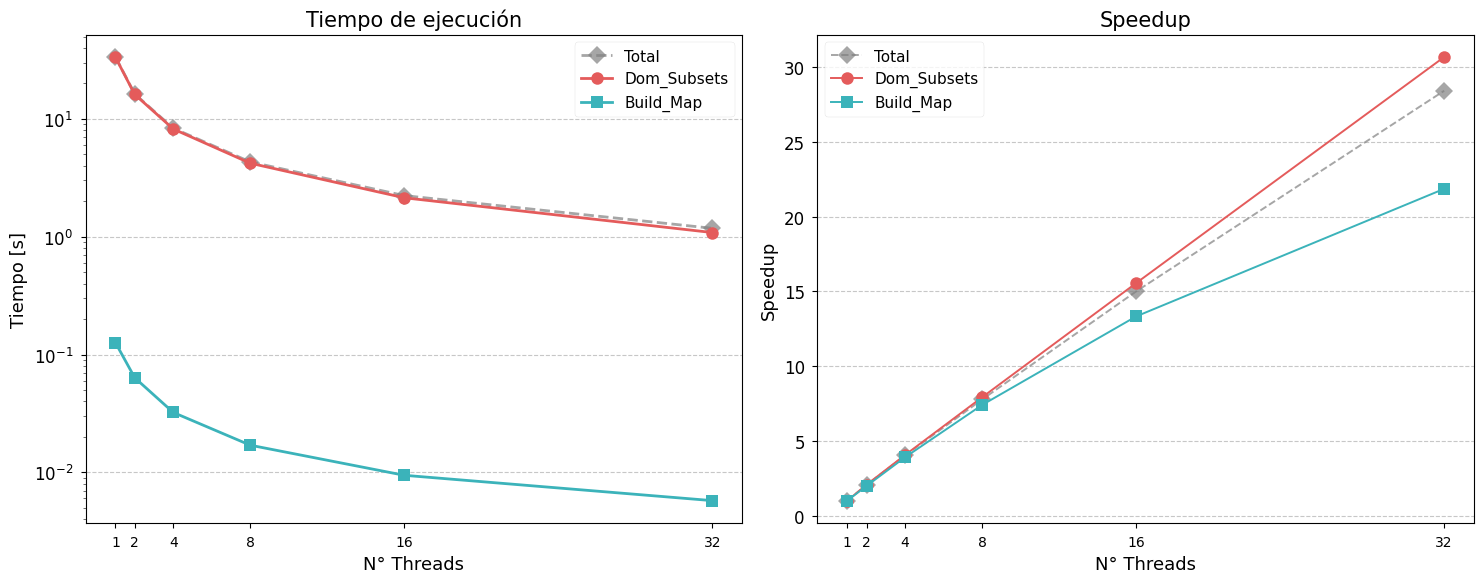

In [13]:
#Filtrar dataset por nombre
dataset_df = df[df["filename"] == dataset_name].sort_values(by="num_threads")

threads = dataset_df["num_threads"].unique()
# time_sc = dataset_df[pd.isna(dataset_df["type"])]["grasp_time"]

# speedup_grasp = time_sc[threads == 1].values[0] / time_sc

# plt.figure(figsize=(10, 6))

column_time_sequential = column_time[0]
create_map_sequential = create_map[0]
total_sequential = total_time[0]

speedup_column = [column_time_sequential / t for t in column_time]
speedup_create_map = [create_map_sequential / t for t in create_map]
speedup_total = [total_sequential / t for t in total_time]

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)

plt.plot(threads, total_time, marker='D', label='Total', linewidth=2, color='gray', linestyle='--', alpha=0.7)
plt.plot(threads, column_time, marker='o', label='Dom_Subsets', linewidth=2, color=red)
plt.plot(threads, create_map, marker='s', label='Build_Map', linewidth=2, color=cyan)

plt.title('Tiempo de ejecución')
plt.xlabel('N° Threads')
plt.ylabel('Tiempo [s]')
plt.xticks(threads)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.yscale('log')
plt.legend()

plt.subplot(1, 2, 2)

plt.plot(threads, speedup_total, marker='D', label='Total', color='gray', linestyle='--', alpha=0.7)
plt.plot(threads, speedup_column, marker='o', label='Dom_Subsets', color=red)
plt.plot(threads, speedup_create_map, marker='s', label='Build_Map', color=cyan)

plt.title('Speedup')
plt.xlabel('N° Threads')
plt.ylabel('Speedup')
plt.xticks(threads)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()


plt.tight_layout()
plt.savefig(f"images/{dataset_name}_GRASPspeedup.png", dpi=300, bbox_inches='tight')
plt.show()

# MST

### Percentaje of improvement by size

In [327]:
datasets = [
    ["scpe1", "scpe2", "scpe3", "scpe4", "scpe5", "scpclr10", "scpclr11", "scpclr12", "scpclr13", "scpcyc06", "scpcyc07", "scpcyc08", "scpcyc09", "scpcyc10", "scpcyc11"],
    [5, 5, 5, 5, 5, 25, 23, 23, 23, 60, 144, 344, 772, 1792, 3968]
]
bks_map = dict(zip(datasets[0], datasets[1]))
saveFilename = "MSTRPD"
type_seg = "MST"

/tmp/ipykernel_576180/191623709.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_grasp = df_filtered[pd.isna(df["type"])]
/tmp/ipykernel_576180/191623709.py:38: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_time_grasp = df_filtered[pd.isna(df["type"])].copy()


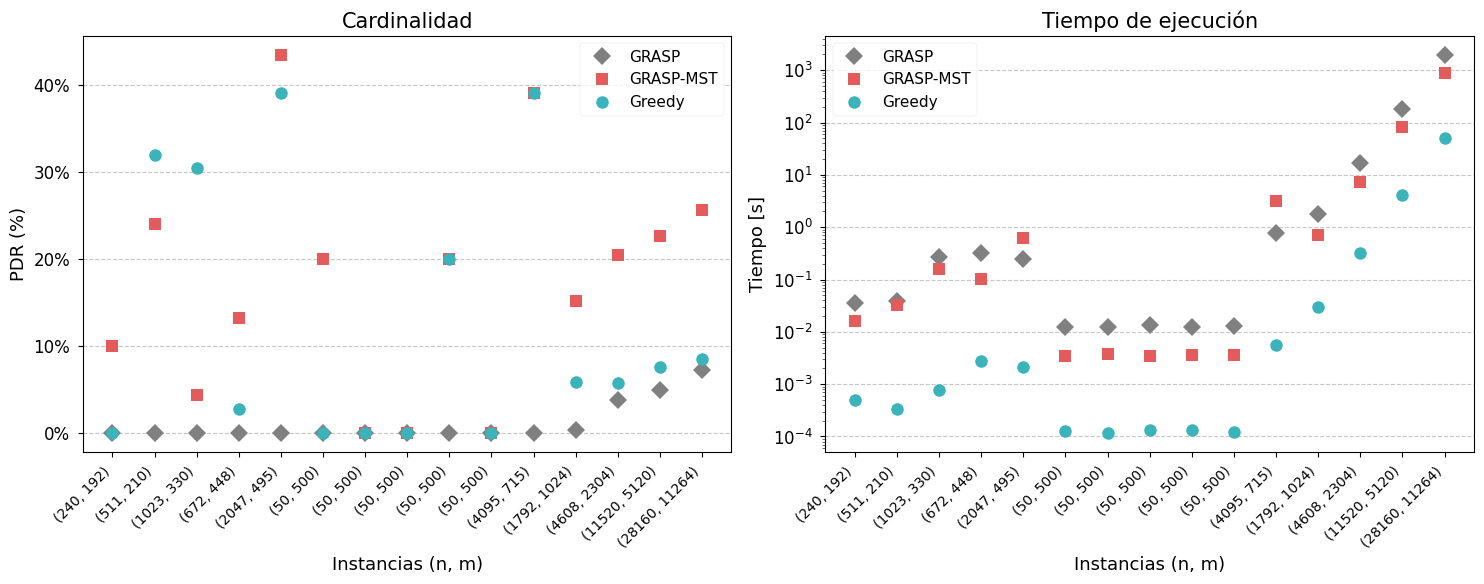

In [328]:
df_filtered = df[df["filename"].isin(datasets[0])].copy()
df_filtered["instance_size"] = df_filtered.apply(lambda row: f"({row['n']}, {row['m']})", axis=1)
df_sc = df_filtered[df_filtered["type"] == type_seg]
df_sc = df_sc.loc[df_sc.groupby("filename")["grasp_size"].idxmin()].reset_index(drop=True)
df_sc['BKS'] = df_sc['filename'].map(bks_map)
df_sc.sort_values(by=["m", "n"], inplace=True)

df_grasp = df_filtered[pd.isna(df["type"])]
df_grasp = df_grasp.loc[df_grasp.groupby("filename")["grasp_size"].idxmin()].reset_index(drop=True)
df_grasp['BKS'] = df_grasp['filename'].map(bks_map)
df_grasp.sort_values(by=["m", "n"], inplace=True)

df_sc["impr_grasp"] = ((df_sc["grasp_size"] - df_sc["BKS"]) / df_sc["BKS"]) * 100
df_sc["impr_greedy"] = ((df_sc["greedy_size"] - df_sc["BKS"]) / df_sc["BKS"]) * 100
df_grasp["impr_grasp"] = ((df_grasp["grasp_size"] - df_grasp["BKS"]) / df_grasp["BKS"]) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
x = np.arange(len(df_sc["instance_size"]))

ax1.plot(x, df_grasp["impr_grasp"], marker='D', label='GRASP', linestyle='None', color='gray')
ax1.plot(x, df_sc["impr_grasp"], marker='s', label='GRASP-MST', linestyle='None', color=red)
ax1.plot(x, df_sc["impr_greedy"], marker='o', label='Greedy', linestyle='None', color=cyan)

ax1.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))

ax1.set_xticks(x)
ax1.set_xticklabels(df_sc['instance_size'], rotation=45, ha='right')
ax1.set_xlabel("Instancias (n, m)")
ax1.set_title("Cardinalidad")
ax1.set_ylabel("PDR (%)")
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

df_time_mst = df_filtered[df_filtered["type"] == type_seg].copy()
df_time_mst = df_time_mst[df_time_mst["num_threads"] == 1]
df_time_mst.sort_values(by=["m", "n"], inplace=True)

df_time_grasp = df_filtered[pd.isna(df["type"])].copy()
df_time_grasp = df_time_grasp[df_time_grasp["num_threads"] == 1]
df_time_grasp.sort_values(by=["m", "n"], inplace=True)

ax2.plot(x, df_time_grasp["grasp_time"], marker='D', label='GRASP', linestyle='None', color='gray')
ax2.plot(x, df_time_mst["grasp_time"], marker='s', label='GRASP-MST', linestyle='None', color=red)
ax2.plot(x, df_time_mst["greedy_time"], marker='o', label='Greedy', linestyle='None', color=cyan)

ax2.set_xticks(x)
ax2.set_xticklabels(df_time['instance_size'], rotation=45, ha='right')
ax2.set_xlabel("Instancias (n, m)")
ax2.set_title("Tiempo de ejecución")
ax2.set_ylabel("Tiempo [s]")
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.set_yscale('log')
# ax2.set_ylim(bottom=0)

plt.tight_layout()

plt.savefig(f"images/{saveFilename}.png", dpi=300, bbox_inches='tight')
plt.show()

# UNION-FIND

### Tiempos por fase de grupos

In [24]:
dataset = "test1_20000_32"
seg_time = [10.777079, 7.150374, 3.675877, 1.895392, 1.00394, 0.510797]
grasp_time = [0.356276, 0.182831, 0.102606, 0.058592, 0.041138, 0.033192]
threads = [1, 2, 4, 8, 16, 32]
total = [seg_time[i] + grasp_time[i] for i in range(len(seg_time))]

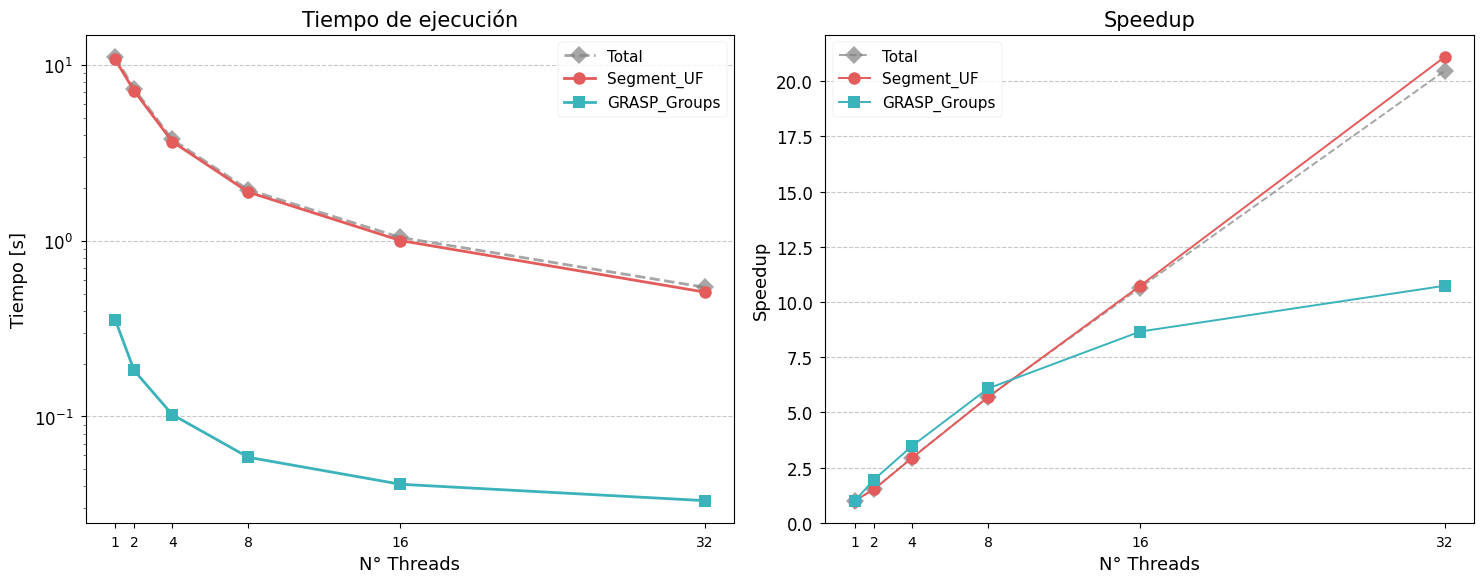

In [26]:
seg_time_sequential = seg_time[0]
grasp_time_sequential = grasp_time[0]
total_sequential = total[0]

speedup_seg = [seg_time_sequential / t for t in seg_time]
speedup_grap = [grasp_time_sequential / t for t in grasp_time]
speedup_total = [total_sequential / t for t in total]

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)

plt.plot(threads, total, marker='D', label='Total', linewidth=2, color='gray', linestyle='--', alpha=0.7)
plt.plot(threads, seg_time, marker='o', label='Segment_UF', linewidth=2, color=red)
plt.plot(threads, grasp_time, marker='s', label='GRASP_Groups', linewidth=2, color=cyan)

plt.title('Tiempo de ejecución')
plt.xlabel('N° Threads')
plt.ylabel('Tiempo [s]')
plt.xticks(threads)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.yscale('log')
plt.legend()

plt.subplot(1, 2, 2)

plt.plot(threads, speedup_total, marker='D', label='Total', color='gray', linestyle='--', alpha=0.7)
plt.plot(threads, speedup_seg, marker='o', label='Segment_UF', color=red)
plt.plot(threads, speedup_grap, marker='s', label='GRASP_Groups', color=cyan)

plt.title('Speedup')
plt.xlabel('N° Threads')
plt.ylabel('Speedup')
plt.xticks(threads)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.savefig(f"images/fases_{dataset}_speedup.png", dpi=300, bbox_inches='tight')
plt.show()

### Cardinalidad por tamaño

In [27]:
filenames = [
    "test2_1000_4",
    "test2_5000_4",
    "test2_10000_4",
    "test2_20000_4",
    "test2.1_1000_4",
    "test2.1_10000_4",
    "test2.1_20000_4"
]
type_seg = "UF"
num_groups = 4

In [30]:
filenames = [
    "test3_1000_32",
    "test3_5000_32",
    "test3_10000_32",
    "test3_20000_32",
    "test3.1_1000_32",
    "test3.1_10000_32",
    "test3.1_20000_32"
]
type_seg = "UF"
num_groups = 32

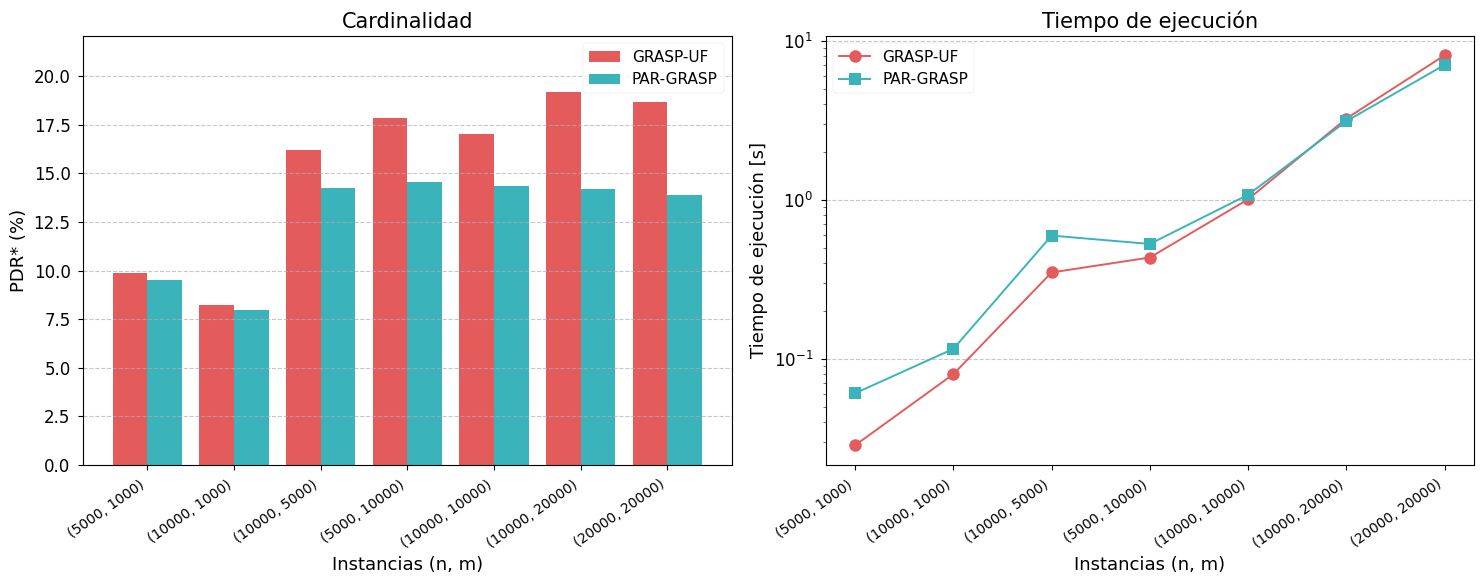

In [ ]:
df_filtered = df[df["filename"].isin(filenames)]
df_type = df_filtered[df_filtered["type"] == type_seg]
df_type = df_type.loc[df_type.groupby("filename")["grasp_size"].idxmin()].reset_index(drop=True)
df_type.sort_values(by=["m", "n"], inplace=True)
df_sc = df_filtered[pd.isna(df_filtered["type"])]
df_sc = df_sc.loc[df_sc.groupby("filename")["grasp_size"].idxmin()].reset_index(drop=True)
df_sc.sort_values(by=["m", "n"], inplace=True)

df_type["improvement_percent"] = ((df_type["greedy_size"] - df_type["grasp_size"]) / df_type["greedy_size"]) * 100
df_type["instance_size"] = df_type.apply(lambda row: f"({row['n']}, {row['m']})", axis=1)

df_sc["improvement_percent"] = ((df_sc["greedy_size"] - df_sc["grasp_size"]) / df_sc["greedy_size"]) * 100
df_sc["instance_size"] = df_sc.apply(lambda row: f"({row['n']}, {row['m']})", axis=1)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
x = np.arange(len(df_type["instance_size"]))
width = 0.4

ax1.bar(x - width/2, df_type["improvement_percent"], width, label='GRASP-UF', color=red)
ax1.bar(x + width/2, df_sc["improvement_percent"], width, label='PAR-GRASP', color=cyan)

max_improvement = max(df_type["improvement_percent"].max(), df_sc["improvement_percent"].max())
ax1.set_ylim(0, max_improvement * 1.15)

ax1.set_xticks(x, df_type['instance_size'], rotation=35, ha='right')
ax1.set_title("Cardinalidad")
ax1.set_xlabel("Instancias (n, m)")
ax1.set_ylabel("PDR* (%)")
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

ax2.plot(x, df_type["grasp_time"], marker='o', label='GRASP-UF', color=red)
ax2.plot(x, df_sc["grasp_time"], marker='s', label='PAR-GRASP', color=cyan)

ax2.set_xticks(x, df_type['instance_size'], rotation=35, ha='right')
ax2.set_xlabel("Instancias (n, m)")
ax2.set_ylabel("Tiempo de ejecución [s]")
ax2.set_title("Tiempo de ejecución")
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.set_yscale('log')

plt.tight_layout()
plt.savefig(f"images/UF{num_groups}.png", dpi=300, bbox_inches='tight')
plt.show()

### Cardinalidad por número de grupos

In [32]:
filenames = [
    "test1_20000_1",
    "test1_20000_2",
    "test1_20000_4",
    "test1_20000_8",
    "test1_20000_16",
    "test1_20000_32",
    "test1_20000_64"
]
type_seg = "UF"

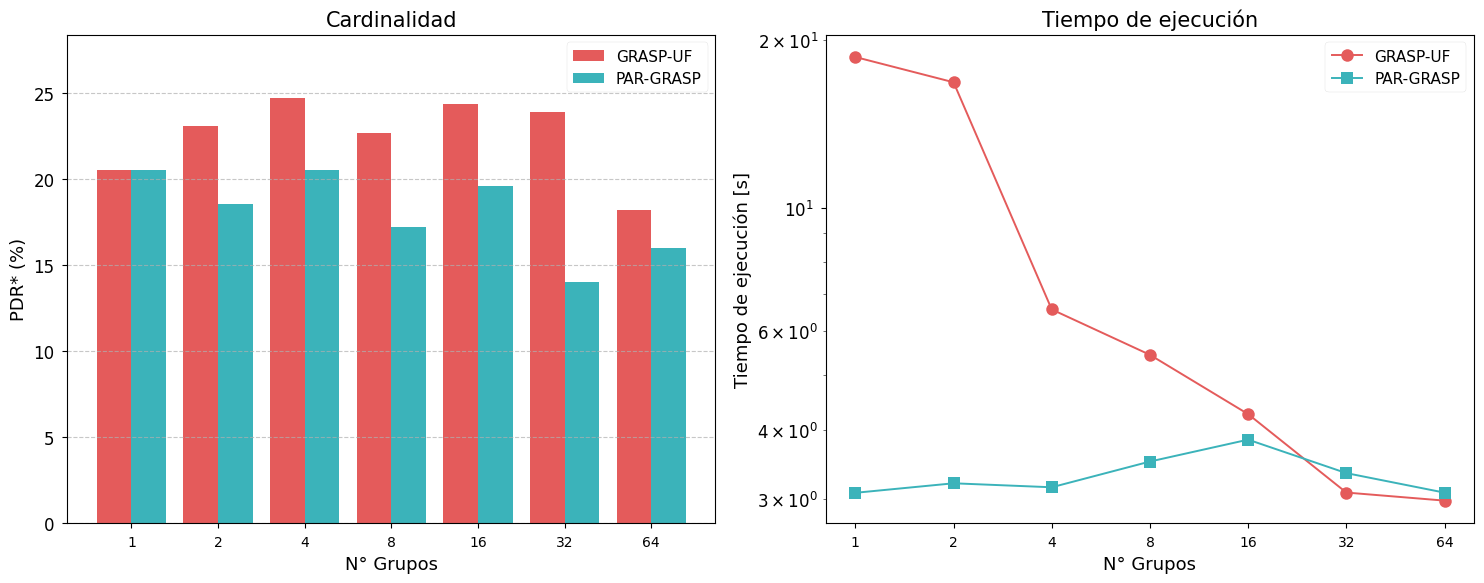

In [35]:
df_filtered = df[df["filename"].isin(filenames)]
df_type = df_filtered[df_filtered["type"] == type_seg]
df_type = df_type.loc[df_type.groupby("filename")["grasp_size"].idxmin()].reset_index(drop=True)
df_type.sort_values(by="num_groups", inplace=True)
df_sc = df_filtered[pd.isna(df_filtered["type"])]
df_sc = df_sc.loc[df_sc.groupby("filename")["grasp_size"].idxmin()].reset_index(drop=True)

df_type["improvement_percent"] = ((df_type["greedy_size"] - df_type["grasp_size"]) / df_type["greedy_size"]) * 100

df_sc["improvement_percent"] = ((df_sc["greedy_size"] - df_sc["grasp_size"]) / df_sc["greedy_size"]) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
x = np.arange(len(df_type["num_groups"]))
width = 0.4

# Graficar
ax1.bar(x - width/2, df_type["improvement_percent"], width, label='GRASP-UF', color=red)
ax1.bar(x + width/2, df_sc["improvement_percent"], width, label='PAR-GRASP', color=cyan)

max_improvement = max(df_type["improvement_percent"].max(), df_sc["improvement_percent"].max())
ax1.set_ylim(0, max_improvement * 1.15)

ax1.set_xticks(x, df_type['num_groups'])
ax1.set_title("Cardinalidad")
ax1.set_xlabel("N° Grupos")
ax1.set_ylabel("PDR* (%)")
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

time_type = df_filtered[df_filtered["num_threads"] == 32].sort_values(by="num_groups")
time_type = time_type[time_type["type"] == type_seg]["grasp_time"]
time_sc = df_filtered[df_filtered["num_threads"] == 32].sort_values(by="num_groups")
time_sc = time_sc[pd.isna(time_sc["type"])]["grasp_time"]

ax2.plot(x, time_type, marker='o', label='GRASP-UF', color=red)
ax2.plot(x, time_sc, marker='s', label='PAR-GRASP', color=cyan)

ax2.set_xticks(x, df_type['num_groups'])
ax2.set_xlabel("N° Grupos")
ax2.set_ylabel("Tiempo de ejecución [s]")
ax2.set_title("Tiempo de ejecución")
ax2.legend()
ax2.set_yscale('log')

plt.tight_layout()
plt.savefig("images/UFNgroups.png", dpi=300, bbox_inches='tight')
plt.show()

In [36]:
time_seg_groups = [
    15.006195,
    13.865565,
    3.735785,
    2.659019,
    1.516085,
    0.510786,
    0.278312
]

time_grasp_groups = [
    0.837408,
    0.345284,
    0.211197,
    0.163678,
    0.163640,
    0.045763,
    0.152873
]

time_grasp_woseg = [
    0.546700,
    0.492376,
    0.466163,
    0.474775,
    0.482987,
    0.635614,
    0.898125
]

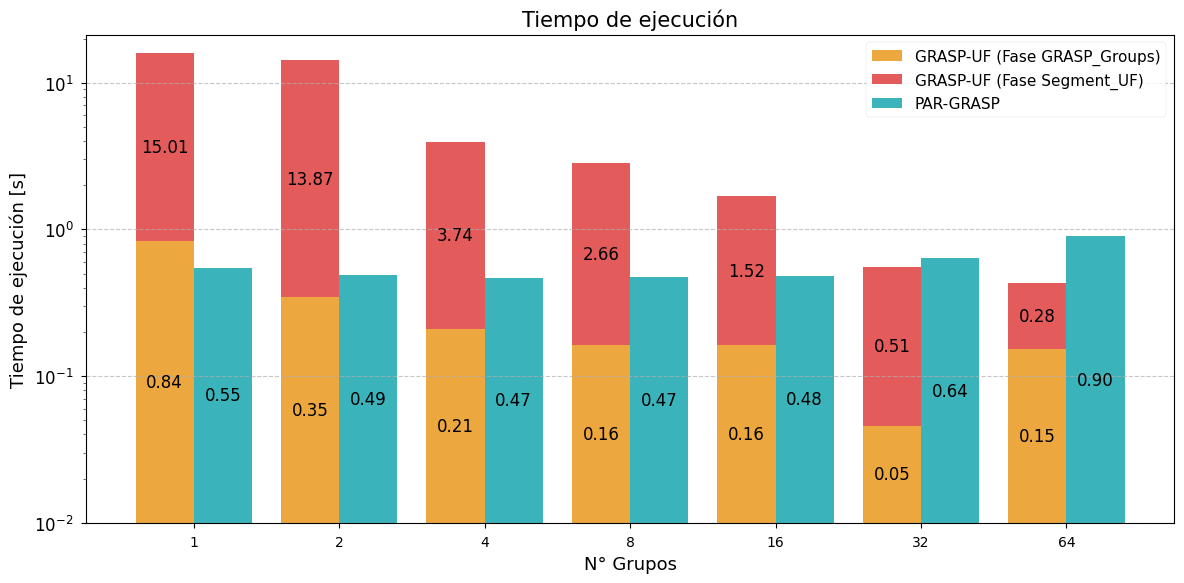

In [38]:
plt.figure(figsize=(12, 6))
x = np.arange(len(df_type["num_groups"]))
width = 0.4

bar1 = plt.bar(x - width/2, time_grasp_groups, width, label='GRASP-UF (Fase GRASP_Groups)', color="#ECA73F")
bar2 = plt.bar(x - width/2, time_seg_groups, width, bottom=time_grasp_groups, label='GRASP-UF (Fase Segment_UF)', color=red)

bar3 = plt.bar(x + width/2, time_grasp_woseg, width, label='PAR-GRASP', color=cyan)

plt.bar_label(bar1, label_type='center', fmt=lambda x: f'{x:.2f}')
plt.bar_label(bar2, label_type='center', fmt=lambda x: f'{x:.2f}')
plt.bar_label(bar3, label_type='center', fmt=lambda x: f'{x:.2f}')


plt.xticks(x, df_type['num_groups'])
plt.xlabel("N° Grupos")
plt.ylabel("Tiempo de ejecución [s]")
plt.title("Tiempo de ejecución")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.yscale('log')
plt.ylim(bottom=0.01)

plt.tight_layout()
plt.savefig("images/fasesGroups.png", dpi=300, bbox_inches='tight')
plt.show()